In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [4]:
with zipfile.ZipFile("/content/archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall("data")
print("file extract successfully ")

df = pd.read_csv("data/IMDB Dataset.csv")


file extract successfully 


In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
df.isnull().sum()

,0
review,0
sentiment,0


In [9]:
df.shape

(50000, 2)

In [10]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [11]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [12]:
df.duplicated().sum()

np.int64(418)

In [13]:
df.duplicated().head(10)

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

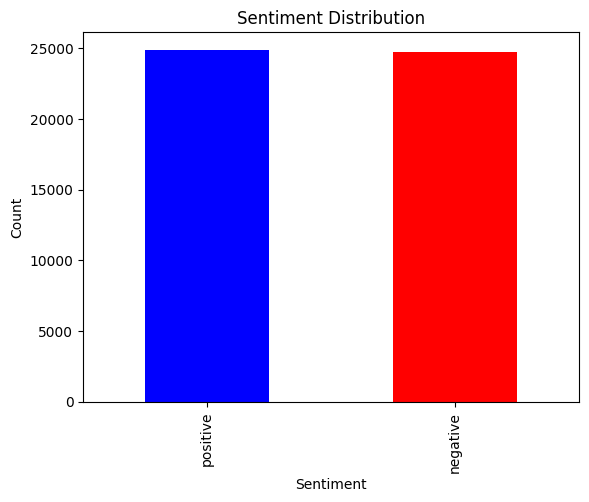

(<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>,
 None)

In [16]:
df["sentiment"].value_counts().plot(kind="bar",color=["blue","red"])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt,plt.show()

In [17]:
df["review_length"] = df["review"].apply(len)
df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [18]:
df["review_length"].describe()

,review_length
count,49582.000000
mean,1310.568230
std,990.762238
min,32.000000
25%,699.000000
50%,971.000000
75%,1592.000000
max,13704.000000


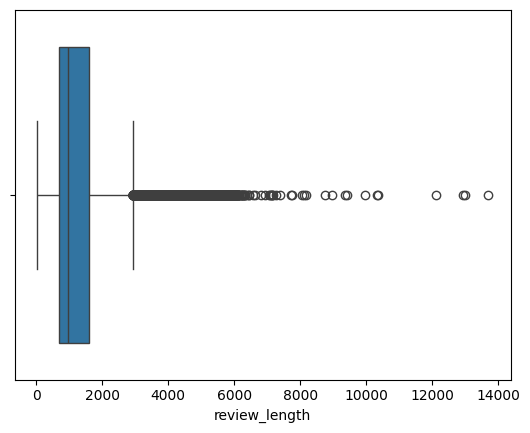

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["review_length"])
plt.show()

In [20]:
Q1 = df["review_length"].quantile(0.25)
Q3 = df["review_length"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["review_length"] < lower) |
              (df["review_length"] > upper)]

print(outliers.shape)

(3705, 3)


In [21]:
df.groupby("sentiment")["review_length"].mean()

,review_length
sentiment,
negative,1294.739615
positive,1326.278532


In [22]:
df.shape

(49582, 3)

In [23]:
print(df["review"][0])
print(df["review"][1])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [24]:
df["review"] = df["review"].str.lower()

In [25]:
print(df["review"].iloc[0])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fac

In [26]:

from bs4 import BeautifulSoup

def remove_html_tags(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

df["review"] = df["review"].apply(remove_html_tags)

In [27]:
print(df["review"].iloc[0])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wou

In [28]:
import string

def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, "")
    return text

df["review"] = df["review"].apply(remove_punctuations)

In [29]:
print(df["review"].iloc[0])

one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty picture

In [30]:
import re

def remove_numbers(text):
    text = re.sub(r'\d+', '', text)
    return text

df["review"] = df["review"].apply(remove_numbers)

In [31]:
print(df["review"].iloc[0])

one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures

In [32]:
df.head()

,review,sentiment,review_length
0,one of the other reviewers has mentioned that ...,positive,1761
1,a wonderful little production the filming tech...,positive,998
2,i thought this was a wonderful way to spend ti...,positive,926
3,basically theres a family where a little boy j...,negative,748
4,petter matteis love in the time of money is a ...,positive,1317


In [33]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize

df["tokens"] = df["review"].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [34]:
df.head()

,review,sentiment,review_length,tokens
0,one of the other reviewers has mentioned that ...,positive,1761,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,998,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,926,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically theres a family where a little boy j...,negative,748,"[basically, theres, a, family, where, a, littl..."
4,petter matteis love in the time of money is a ...,positive,1317,"[petter, matteis, love, in, the, time, of, mon..."


In [35]:
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda x: [word for word in x if word not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [36]:
nltk.download("wordnet")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [37]:
df["clean_review"] = df["tokens"].apply(
    lambda x: " ".join(x)
)

In [38]:
df[["review", "clean_review"]].head()

,review,clean_review
0,one of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,a wonderful little production the filming tech...,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...


In [39]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["sentiment"] = encoder.fit_transform(df["sentiment"])

df["sentiment"].value_counts()

,count
sentiment,
1,24884
0,24698


In [40]:
print(encoder.classes_)

['negative' 'positive']


In [41]:
df["sentiment"].head()

,sentiment
0,1
1,1
2,1
3,0
4,1


In [42]:
print(df["clean_review"].iloc[0])

one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl sold nickel inmate wholl kill order get away well mannered middle class inmate turned prison bitc

In [43]:
X = df["clean_review"]
y = df["sentiment"]

In [44]:
y = df["sentiment"]
print(y.shape)

(49582,)


In [45]:
print(X)

0        one reviewer mentioned watching oz episode you...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movie high art fan expec...
Name: clean_review, Length: 49582, dtype: object


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(39665,) (9917,)
(39665,) (9917,)


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train)

In [54]:
X_test = tfidf.transform(X_test)

In [55]:
lr = LogisticRegression (max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [56]:
y_pred = lr.predict(X_test)



In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4940
           1       0.87      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8822224463043259


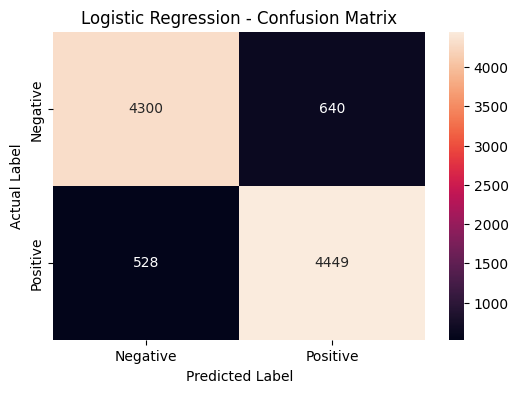

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [60]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [61]:
y_pred_nb = nb.predict(X_test)

In [62]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4940
           1       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



In [63]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.8512655036805485


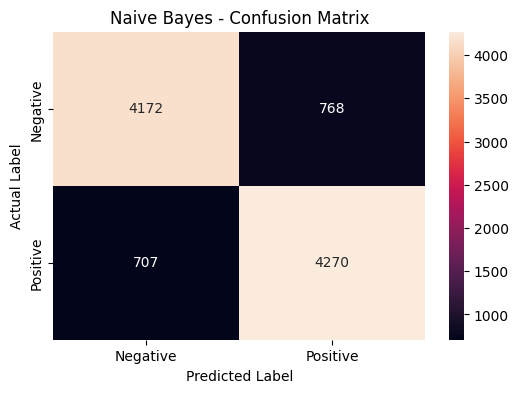

In [64]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Naive Bayes - Confusion Matrix")

plt.show()


In [65]:
svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

In [66]:
y_pred_svm = svm.predict(X_test)

In [67]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4940
           1       0.87      0.88      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [68]:
print("Accuracy", accuracy_score(y_test, y_pred_svm))

Accuracy 0.8756680447716043


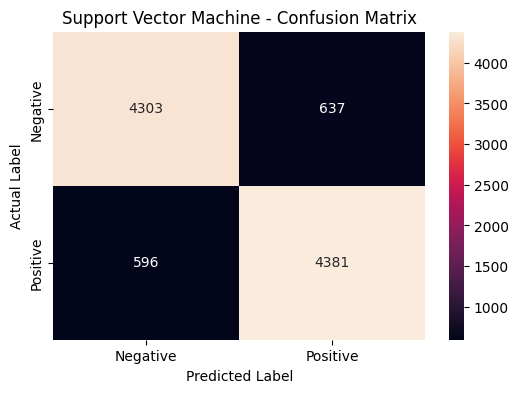

In [69]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Support Vector Machine - Confusion Matrix")

plt.show()

In [70]:
train_pred_lr = lr.predict(X_train)

from sklearn.metrics import accuracy_score

print("Logistic Regression Train Accuracy:",
      accuracy_score(y_train, train_pred_lr))

Logistic Regression Train Accuracy: 0.9088365057355351


In [71]:
train_pred_svm = svm.predict(X_train)

print("SVM Train Accuracy:",
      accuracy_score(y_train, train_pred_svm))

SVM Train Accuracy: 0.9270893735030884


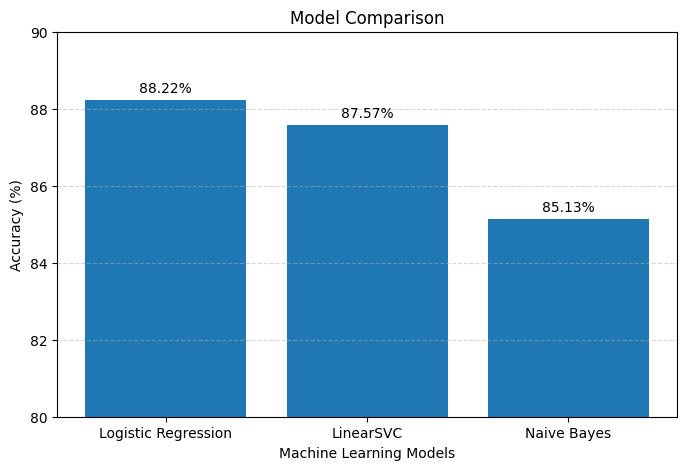

In [72]:
import matplotlib.pyplot as plt

# Model names
models = ["Logistic Regression", "LinearSVC", "Naive Bayes"]

# Accuracy values
accuracy = [88.22, 87.57, 85.13]

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy)

# Add accuracy values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.2f}%",
        ha='center'
    )

plt.title("Model Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# **Model Comparison**

Logistic Regression achieved the highest accuracy (88.48%) and was selected as the final model.

LinearSVC achieved 87.68%, performing slightly below Logistic
Regression.

Multinomial Naive Bayes achieved 85.07%, making it the lowest-performing model among the three.

Based on the evaluation results, Logistic Regression was chosen as the final model for sentiment prediction.

In [73]:
import joblib

joblib.dump(lr, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
